In [450]:
# pyright: reportOperatorIssue=false

In [451]:
import sympy as sp
from sympy.printing.latex import LatexPrinter

from IPython.display import display, Math, Markdown

In [452]:
# Main parameters
dx = sp.Symbol('dx', latex=r'\Delta x', positive=True, real=True)
dt = sp.Symbol('dt', latex=r'\Delta t', positive=True, real=True)

a = sp.Symbol('a', positive=True, real=True)
cfl = sp.Symbol('cfl', latex=r'\nu', positive=True, real=True)
sigma = sp.Symbol('sigma', latex=r'\sigma', real=True)

# dx and dt latex symbols (passed in sp.Symbol()) seem to be hard-coded to use 
# symbol names, this is a codegen-friendly work-around
symbol_names = {dx: r"\Delta x", dt: r"\Delta t", cfl: r"\nu"}
LatexPrinter.set_global_settings(symbol_names=symbol_names)

In [453]:
# Derivatives
u = sp.Symbol('u')
u_x = sp.Symbol(r"u'_x")
u_xx = sp.Symbol(r"u''_{xx}")
u_xxx = sp.Symbol(r"u'''_{xxx}")
u_4x = sp.Symbol(r"u^{(IV)}_{xxxx}")
u_5x = sp.Symbol(r"u^{(V)}_{xxxxx}")
u_6x = sp.Symbol(r"u^{(VI)}_{xxxxxx}")

derivs = [u, u_x, u_xx, u_xxx, u_4x, u_5x, u_6x]


def taylor_spatial(offset: int, order: int=6) -> sp.Expr:
    """ Taylor expansion of u(x + offset*dx, t) around (x, t) """
    result = sp.S.Zero
    for k in range(min(order + 1, len(derivs))):
        # One can try to use sp.Mul & friends to try and appease the typecheck gods``
        result += derivs[k] * (offset * dx)**k / sp.factorial(k)
    return result

In [454]:
# Stencil
u_im2 = sp.Symbol('u_im2')
u_im1 = sp.Symbol('u_im1')
u_i = sp.Symbol('u_i')
u_ip1 = sp.Symbol('u_ip1')
u_ip2 = sp.Symbol('u_ip2')

# A bit crude
stencil_offsets = {
    stencil_point: offset for offset, stencil_point in
    enumerate([u_im2, u_im1, u_i, u_ip1, u_ip2], start=-2)
}

# This is just appears to be a better practice with sympy
symbol_names |= {
    u_im2: "u^n_{i - 2}",
    u_im1: "u^n_{i - 1}",
    u_i: "u^n_i",
    u_ip1: "u^n_{i + 1}",
    u_ip2: "u^n_{i + 2}",
}
LatexPrinter.set_global_settings(symbol_names=symbol_names)


def expand_to_taylor(expr: sp.Expr) -> sp.Expr:
    """Helper function to substitute Taylor expansions in stencil points"""
    return sp.simplify(expr.subs(
        {stencil_point: taylor_spatial(offset)
         for stencil_point, offset in stencil_offsets.items()}
    ))

In [455]:
# Sanity check
display(Markdown("Taylor expansions:"))
for stencil_point, offset in stencil_offsets.items():
    if offset != 0:
        display(Math(
            fr"{symbol_names[stencil_point]} = {sp.latex(taylor_spatial(offset), order='rev-lex')} + \ldots"
        ))

Taylor expansions:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [456]:
u_next: sp.Expr = \
    sigma * u_i + (1 - sigma) * (u_ip1 + u_im1) / 2 \
    + -a * dt * (u_ip1 - u_im1) / (2 * dx) \
    + (a * dt)**2 / 2 * (u_ip1 - 2 * u_i + u_im1) / dx**2

# TODO -- this is easily programmable
u_exact_taylor: sp.Expr = (u
                    - a * dt * u_x
                    + a**2 * dt**2 / 2 * u_xx
                    - a**3 * dt**3 / 6 * u_xxx
                    + a**4 * dt**4 / 24 * u_4x
                    - a**5 * dt**5 / 120 * u_5x
                    + a**6 * dt**6 / 720 * u_6x)

In [457]:
def to_stencil_form(expr: sp.Expr) -> sp.Expr:
    """ Helper function """
    return sp.collect(sp.expand(expr), [u_im2, u_im1, u_i, u_ip1, u_ip2])

In [458]:
# display(Markdown(""))
display(Math(
    f"u_i^{{n+1}} = {sp.latex(sp.simplify(to_stencil_form(u_next)))}"
))
display(Math(
    f"u_i^{{n+1}} = {sp.latex(sp.simplify(sp.collect(sp.expand(expand_to_taylor(u_next)), derivs)))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [459]:
def get_coeff(expr, deriv):
    return sp.together(sp.simplify(sp.expand(expr).coeff(deriv)))


u_next_taylor = expand_to_taylor(u_next)
error = sp.expand(u_next_taylor - u_exact_taylor)

error_coeffs = list(map(lambda deriv: get_coeff(error, deriv), derivs))

In [460]:
table = r"""
\begin{array} {r r r} \\
& \text{Coefficient} & \text{Error coefficient} \\
\hline \\
"""

# Decorative function only
pretty_derivs_symbol_names = {
    deriv: fr"\dfrac{{\partial^{k} u}}{{\partial x^{k}}}"
    for k, deriv in enumerate(derivs)
} | {u: "u", u_x: r"\dfrac{\partial u}{\partial x}"}

for deriv, error_coeff in zip(derivs, error_coeffs):
    table += fr"{sp.latex(deriv, symbol_names=pretty_derivs_symbol_names)} : &\quad \
                    {sp.latex(get_coeff(u_next_taylor, deriv), fold_short_frac=True)} &\quad \
                    {sp.latex(error_coeff, fold_short_frac=True)} \\[1em]"

table += r"\end{array}"
display(Math(table))

<IPython.core.display.Math object>

The goal here is to strip away the common factors (like $\Delta t$, $\Delta x$, and factorial denominators from the Taylor series) to isolate the "raw" constants of the error.
*   **`* sp.factorial(k)`**: Cancels out the $1/k!$ term from the Taylor expansion.
*   **`* 6 / (a**3 * dt**3 * dx**k)`**: The leading order of the error for this specific scheme is expected to be $O(a^3 \Delta t^3)$. Dividing by this normalizes the error terms, essentially asking: *"What is the coefficient of the $k$-th derivative relative to the leading error term?"*

In [461]:
error_coeffs_normalized = [
    sp.simplify(error_coeffs[k] * sp.factorial(k) * 6 / (a**3 * dt**3 * dx**k))
    for k in range(5)]

error_coeffs_normalized = sp.Matrix(error_coeffs_normalized)

# error_coeffs[k] +=(a**4 * dt**4 - a**2 * dt**2 * dx**2)
# error_coeffs_normalized[4] = 0
error_coeffs_normalized[4] += ((sigma - 1) * dx**4) * 6 /(a**3 * dt**3 * dx**4)
# error_coeffs_normalized[4] += (a**4 * dt**4 - a**2 * dt**2 * dx**2) * 6 /(a**3 * dt**3 * dx**4)

# pretty printing factoring out of constant
# TODO -- can be factored out into a helper function
display(Math(
        fr"{sp.latex((gcd := sp.gcd(tuple(error_coeffs_normalized.flat()))))} \cdot \
              {sp.latex(sp.simplify((error_coeffs_normalized.T / gcd)))}^T"
        ))

<IPython.core.display.Math object>

This creates a $5 \times 5$ matrix representing the "structure" of the 5-point stencil ($u_{i-2}$ to $u_{i+2}$). 
*   Each row corresponds to a derivative order $k$ ($0, 1, 2, 3, 4$).
*   Each column corresponds to a stencil offset ($-2, -1, 0, 1, 2$).
*   Because we already accounted for $1/k!$ and $\Delta x^k$ in the normalization step, the Taylor coefficient for offset $j$ and order $k$ is simply $j^k$. (The `0**k if k > 0 else 1` handles the $0^0 = 1$ edge case for the $u_i$ term).

In [462]:
taylor_coeffs_normalized = sp.Matrix([
    [(-2)**k, (-1)**k, 0**k if k > 0 else 1, 1**k, 2**k]
    for k in range(5)
])

display(Math(
    fr"{sp.latex(taylor_coeffs_normalized)} x = 6 \
        \cdot {sp.latex(error_coeffs_normalized / 6)},\\[2em]"
))

solution: sp.Matrix = taylor_coeffs_normalized.solve(error_coeffs_normalized)

# pretty printing factoring out of denominator
display(Math(
    fr"x = {sp.latex(1 / (denom_gcd := 4 * dt**3 * dx**4 * a**3))} \
        \cdot {sp.latex(sp.simplify(solution * denom_gcd))}"
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [463]:
correction_term: sp.Expr = -a ** 3 * dt ** 3 / 6 * (
    solution.dot([u_im2, u_im1, u_i, u_ip1, u_ip2]))
u_corrected: sp.Expr = u_next + correction_term
error_corrected: sp.Expr = sp.expand(
    expand_to_taylor(u_corrected) - u_exact_taylor)

In [464]:
to_stencil_form(u_corrected)

u_i*(a**4*dt**4/(4*dx**4) - 5*a**2*dt**2/(4*dx**2) - sigma/4 + 5/4) + u_im1*(-a**4*dt**4/(6*dx**4) - a**3*dt**3/(6*dx**3) + 2*a**2*dt**2/(3*dx**2) + 2*a*dt/(3*dx) + sigma/6 - 1/6) + u_im2*(a**4*dt**4/(24*dx**4) + a**3*dt**3/(12*dx**3) - a**2*dt**2/(24*dx**2) - a*dt/(12*dx) - sigma/24 + 1/24) + u_ip1*(-a**4*dt**4/(6*dx**4) + a**3*dt**3/(6*dx**3) + 2*a**2*dt**2/(3*dx**2) - 2*a*dt/(3*dx) + sigma/6 - 1/6) + u_ip2*(a**4*dt**4/(24*dx**4) - a**3*dt**3/(12*dx**3) - a**2*dt**2/(24*dx**2) + a*dt/(12*dx) - sigma/24 + 1/24)

In [465]:
for deriv in derivs:
    coeff = sp.simplify(get_coeff(error_corrected, deriv))
    if coeff != 0 or False:
        display(Markdown(
            f"Coefficient of highest-order error term ${sp.latex(deriv)}$:"
        ))
        display(Math(f"{sp.latex(coeff)}"))
        break

Coefficient of highest-order error term $u^{(IV)}_{xxxx}$:

<IPython.core.display.Math object>

In [466]:
u_corrected_cfl: sp.Expr = sp.simplify(u_corrected.subs(a*dt, cfl*dx))

# Sanity checks
assert u_corrected_cfl.coeff(a) == 0 and u_corrected_cfl.coeff(dt) == 0, \
    "Unexpected form after rewrite"

stencil_points_coeffs = [
    get_coeff(u_corrected_cfl, stencil_point)
    for stencil_point in [u_im2, u_im1, u_i, u_ip1, u_ip2]]

assert sp.simplify(sum(stencil_points_coeffs)) == 1, \
    "Coefficients don't sum to 1"

In [467]:
display(Markdown("Complete numerical scheme (CFL form):"))

display(Math(
    fr"u_i^{{n+1}} = {sp.latex(sp.simplify(to_stencil_form(u_corrected_cfl)), order='grlex')}"
))

expand_to_taylor(u_corrected_cfl)

Complete numerical scheme (CFL form):

<IPython.core.display.Math object>

cfl**4*dx**6*u^{(VI)}_{xxxxxx}/144 + cfl**4*dx**4*u^{(IV)}_{xxxx}/24 - cfl**3*dx**5*u^{(V)}_{xxxxx}/24 - cfl**3*dx**3*u'''_{xxx}/6 - cfl**2*dx**6*u^{(VI)}_{xxxxxx}/180 + cfl**2*dx**2*u''_{xx}/2 + cfl*dx**5*u^{(V)}_{xxxxx}/30 - cfl*dx*u'_x - dx**6*sigma*u^{(VI)}_{xxxxxx}/144 + dx**6*u^{(VI)}_{xxxxxx}/144 - dx**4*sigma*u^{(IV)}_{xxxx}/24 + dx**4*u^{(IV)}_{xxxx}/24 + u

In [468]:
def save_to_python_module(expr, filename: str = "mlf_method.py"):
    """Save the complete method as a Python module."""
    
    module_content = f'''
"""
Programmatically-generated Lax-Friedrichs-type 4th-order scheme for solving the
advection equation.
"""

import numpy as np
import numpy.typing as npt

def mlf_step(
    u: npt.NDArray[np.floating],
    dx: np.floating, cfl: np.floating, sigma: np.floating, **_,
) -> npt.NDArray[np.floating]:
    """
    Apply the method using array indexing.
    
    Parameters
    ----------
    u
        Current solution array
    dx
        Spatial step size
    cfl
        CFL number (nu = a*dt/dx)
    sigma
        Dissipation parameter
    
    Returns
    -------
    u_next
        Updated value(s)
    """
    u_next = np.zeros_like(u)
    i = np.arange(2, len(u) - 2)

    u_im2 = u[i-2]
    u_im1 = u[i-1]
    u_i = u[i]
    u_ip1 = u[i+1]
    u_ip2 = u[i+2]

    # TODO -- add mypy warning supression
    # pylint: disable=line-too-long
    u_next[i] = {sp.printing.pycode(expr)}
    return u_next
'''
    
    with open(filename, 'w') as file:
        file.write(module_content)
        print(f"Saved method to {filename}")
    

save_to_python_module(u_corrected_cfl, "mlf_method.py")

Saved method to mlf_method.py


# Stability analysis

In [469]:
def amplification_factor(coeffs: list, theta: sp.Symbol) -> sp.Expr:
    """Return G(theta) = sum c_j * exp(I * j * theta)."""
    I = sp.I  # noqa: E741
    j_vals = [-2, -1, 0, 1, 2]
    G = sum(c * sp.exp(I * j * theta) for c, j in zip(coeffs, j_vals))
    return sp.simplify(G)

In [470]:
def squared_modulus(G: sp.Expr, theta: sp.Symbol) -> sp.Expr:
    """Return |G|^2 as a real trigonometric expression in theta."""
    G_conjugate = sp.conjugate(G).replace(sp.conjugate(theta), theta)  # theta is real
    G_mod_sq = sp.simplify(sp.expand_complex(G * G_conjugate))
    return G_mod_sq

In [471]:
def critical_thetas(G: sp.Expr, theta: sp.Symbol) -> list:
    """Find stationary points of |G|^2 w.r.t. theta in [0, pi]."""
    d_mod = sp.simplify(sp.diff(squared_modulus(G, theta), theta))
    # solve d_mod = 0; often yields simple trigonometric equations
    solutions = sp.solve(d_mod, theta, domain=sp.Interval(0, sp.pi))
    return list(solutions)

In [472]:
def analytical_stability_condition(coeffs: list, cfl: sp.Symbol, theta: sp.Symbol) -> sp.Expr:
    """
    Attempt to find the condition on cfl such that |G|^2 <= 1 for all theta.
    Often works by substituting the worst-case theta (e.g., theta=pi) and solving.
    """
    G = amplification_factor(coeffs, theta)
    G_mod_sq = squared_modulus(G, theta)
    
    # For many upwind/central schemes the maximum occurs at theta = pi or 0
    worst_cases = [0, sp.pi]
    conditions = [G_mod_sq.subs(theta, tc) <= 1 for tc in worst_cases]
    # Solve inequalities
    cfl_cond = sp.simplify(sp.solve_univariate_inequality(conditions[0] & conditions[1], cfl))
    return cfl_cond

In [473]:
theta = sp.Symbol('theta', real=True)

stencil = [u_im2, u_im1, u_i, u_ip1, u_ip2]
coeffs = stencil_points_coeffs

In [474]:
G = amplification_factor(coeffs, theta)

display(Markdown("Amplification factor:"))
display(G)

# G_mod_sq = squared_modulus(G, theta)
# display(G_mod_sq)

Amplification factor:

(cfl**4 + 2*cfl**3 - cfl**2 - 2*cfl - sigma + 4*(-cfl**4 - cfl**3 + 4*cfl**2 + 4*cfl + sigma - 1)*exp(I*theta) + (6*cfl**4 - 30*cfl**2 - 6*sigma + 4*(-cfl**4 + cfl**3 + 4*cfl**2 - 4*cfl + sigma - 1)*exp(I*theta) + (cfl**4 - 2*cfl**3 - cfl**2 + 2*cfl - sigma + 1)*exp(2*I*theta) + 30)*exp(2*I*theta) + 1)*exp(-2*I*theta)/24

cfl**8*sin(theta)**4/36 - 2*cfl**8*sin(theta)**2/9 - 7*cfl**8*cos(theta)/36 - cfl**8*cos(3*theta)/36 + 2*cfl**8/9 - cfl**6*sin(theta)**4/6 + 5*cfl**6*sin(theta)**2/3 + 19*cfl**6*cos(theta)/12 + 7*cfl**6*cos(3*theta)/36 - 16*cfl**6/9 - cfl**4*sigma*sin(theta)**4/18 + 4*cfl**4*sigma*sin(theta)**2/9 + 7*cfl**4*sigma*cos(theta)/18 + cfl**4*sigma*cos(3*theta)/18 - 4*cfl**4*sigma/9 + 11*cfl**4*sin(theta)**4/36 - 37*cfl**4*sin(theta)**2/9 - 38*cfl**4*cos(theta)/9 - 4*cfl**4*cos(3*theta)/9 + 14*cfl**4/3 + cfl**2*sigma*sin(theta)**4/18 - 13*cfl**2*sigma*sin(theta)**2/9 - 59*cfl**2*sigma*cos(theta)/36 - 5*cfl**2*sigma*cos(3*theta)/36 + 16*cfl**2*sigma/9 - cfl**2*sin(theta)**4/6 + 11*cfl**2*sin(theta)**2/3 + 49*cfl**2*cos(theta)/12 + 13*cfl**2*cos(3*theta)/36 - 40*cfl**2/9 + sigma**2*sin(theta)**4/36 - 2*sigma**2*sin(theta)**2/9 - 7*sigma**2*cos(theta)/36 - sigma**2*cos(3*theta)/36 + 2*sigma**2/9 - sigma*sin(theta)**4/18 + 7*sigma*sin(theta)**2/9 + 19*sigma*cos(theta)/18 + sigma*cos(3*theta)/18 -

In [475]:
# critical_thetas(G, theta)

In [476]:
# cond = analytical_stability_condition(coeffs, cfl, theta)
# try:
#     print("Stability condition:", cond)
# except Exception:
#     print("Analytical approach failed, falling back to numerics.")

In [477]:
import typing

import numpy as np
import numpy.typing as npt
import matplotlib.pyplot as plt
import matplotlib.axes

In [ ]:
G_numeric: typing.Callable[
    [npt.ArrayLike, npt.ArrayLike, np.floating],
    npt.NDArray[np.floating]
] = sp.lambdify((theta, cfl, sigma), G, modules='numpy')

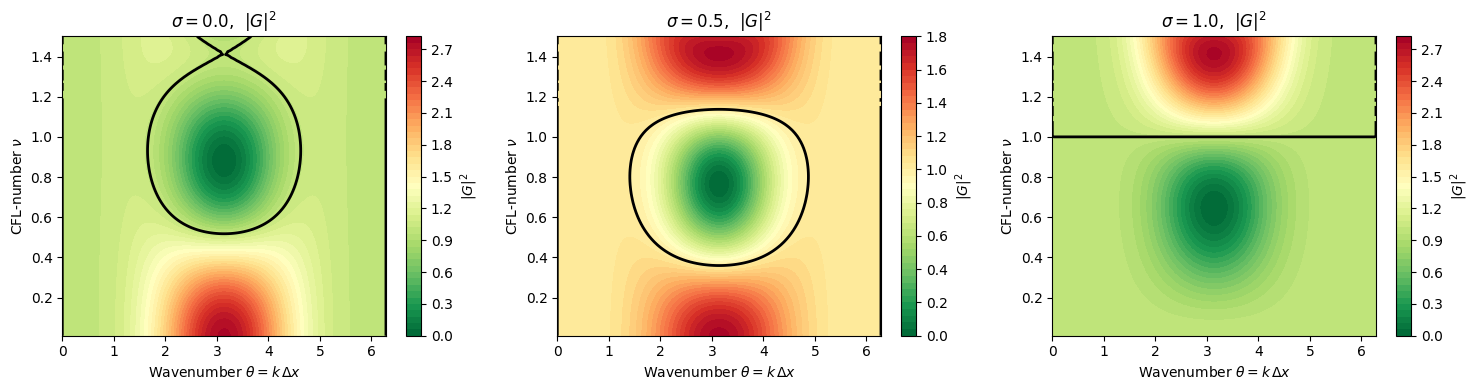


Maximum stable CFL (|G|² ≤ 1 for all θ):
  σ = 0.0: no stable ν found in (0.01, 1.5)
  σ = 0.5: no stable ν found in (0.01, 1.5)
  σ = 1.0: ν_max ≈ 0.9975


In [479]:
def plot_stability_region(sigma_values: typing.Sequence[float]=(0.0, 0.5, 1.0),
                          theta_range: tuple[float, float] = (0.0, 2*np.pi),
                          cfl_range: tuple[float, float] = (0.01, 1.5),
                          n_theta=200, n_cfl=100):
    """Numerically compute and plot |G|^2 over pairs $(\\theta, \\nu)$ for several $\\sigma$."""
    theta_values = np.linspace(*theta_range, n_theta)
    cfl_values = np.linspace(*cfl_range,   n_cfl)
    THETA, CFL = np.meshgrid(theta_values, cfl_values)

    fig, axes = plt.subplots(1, len(sigma_values),
                             figsize=(5 * len(sigma_values), 4),
                             squeeze=False)

    for ax, sigma_value in zip(axes[0], sigma_values):
        ax: matplotlib.axes.Axes
        G_values = G_numeric(THETA, CFL, sigma_value)
        G_mod_sq = np.abs(G_values)**2

        contour = ax.contourf(THETA, CFL, G_mod_sq, levels=50, cmap='RdYlGn_r')
        ax.contour(THETA, CFL, G_mod_sq, levels=[1.0],
                   colors='black', linewidths=2)

        ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
        ax.set_ylabel(r'CFL-number $\nu$')
        ax.set_title(rf'$\sigma = {sigma_value}$,  $|G|^2$')
        fig.colorbar(contour, ax=ax, label=r'$|G|^2$')

    fig.tight_layout()
    plt.show()

    # Maximum stable CFL per sigma
    print("\nMaximum stable CFL (|G|² ≤ 1 for all θ):")
    fine_theta = np.linspace(*theta_range, 1000)
    for sig in sigma_values:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 600):
            G_values = G_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(G_values)**2 <= 1.0 + 1e-10):
                cfl_max = cfl_test
                break
        if cfl_max is not None:
            print(f"  σ = {sig}: ν_max ≈ {cfl_max:.4f}")
        else:
            print(f"  σ = {sig}: no stable ν found in {cfl_range}")


plot_stability_region(sigma_values=(0.0, 0.5, 1.0))

In [480]:
def plot_3d_stability_surface(sigma_range: tuple[float, float] = (0.0, 2.0),
                             theta_range: tuple[float, float] = (0.0, 2*np.pi),
                             cfl_range: tuple[float, float] = (0.01, 1.5),
                             n_sigma=20, n_theta=100, n_cfl=80):
    """3D surface plot showing |G|^2 = 1 stability boundary."""
    
    # Create grid
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    theta_vals = np.linspace(*theta_range, n_theta)
    cfl_vals = np.linspace(*cfl_range, n_cfl)
    
    # Find stability boundary for each (sigma, theta) pair
    SIGMA, THETA = np.meshgrid(sigma_vals, theta_vals)
    CFL_BOUNDARY = np.zeros_like(SIGMA)
    
    for i, sig in enumerate(sigma_vals):
        for j, th in enumerate(theta_vals):
            # Binary search for CFL where |G|^2 = 1
            cfl_low, cfl_high = cfl_range
            for _ in range(50):  # Binary search iterations
                cfl_mid = (cfl_low + cfl_high) / 2
                G_val = G_numeric(th, cfl_mid, sig)
                if np.abs(G_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            CFL_BOUNDARY[j, i] = cfl_mid
    
    # 3D surface plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    surf = ax.plot_surface(SIGMA, THETA, CFL_BOUNDARY, 
                          cmap='viridis', alpha=0.8)
    
    ax.set_xlabel(r'Parameter $\sigma$')
    ax.set_ylabel(r'Wavenumber $\theta$')
    ax.set_zlabel(r'Critical CFL $\nu_{max}$')
    ax.set_title('Stability Boundary Surface')
    
    plt.colorbar(surf, shrink=0.5)
    plt.show()

def plot_max_cfl_vs_sigma(sigma_range: tuple[float, float] = (0.0, 2.0),
                         theta_range: tuple[float, float] = (0.0, 2*np.pi),
                         cfl_range: tuple[float, float] = (0.01, 1.5),
                         n_sigma=100):
    """Plot maximum stable CFL as function of sigma."""
    
    sigma_vals = np.linspace(*sigma_range, n_sigma)
    max_cfl_vals = []
    
    fine_theta = np.linspace(*theta_range, 500)
    
    for sig in sigma_vals:
        cfl_max = None
        for cfl_test in np.linspace(cfl_range[1], cfl_range[0], 300):
            G_values = G_numeric(fine_theta, cfl_test, sig)
            if np.all(np.abs(G_values)**2 <= 1.0 + 1e-12):
                cfl_max = cfl_test
                break
        max_cfl_vals.append(cfl_max if cfl_max is not None else 0)
    
    plt.figure(figsize=(10, 6))
    plt.plot(sigma_vals, max_cfl_vals, 'b-', linewidth=2)
    plt.xlabel(r'Parameter $\sigma$')
    plt.ylabel(r'Maximum stable CFL $\nu_{max}$')
    plt.title('Maximum Stable CFL vs Parameter σ')
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_stability_contours_multi_sigma(sigma_values: list[float] = [0.0, 0.2, 0.5, 0.8, 1.0],
                                       theta_range: tuple[float, float] = (0.0, 2*np.pi),
                                       cfl_range: tuple[float, float] = (0.01, 1.5)):
    """Plot stability boundary contours for multiple sigma values on same plot."""
    
    theta_vals = np.linspace(*theta_range, 300)
    
    plt.figure(figsize=(10, 8))
    
    colors = plt.colormaps['viridis'](np.linspace(0, 1, len(sigma_values)))
    
    for sig, color in zip(sigma_values, colors):
        cfl_boundary = []
        for th in theta_vals:
            # Binary search for boundary CFL
            cfl_low, cfl_high = cfl_range
            for _ in range(40):
                cfl_mid = (cfl_low + cfl_high) / 2
                G_val = G_numeric(th, cfl_mid, sig)
                if np.abs(G_val)**2 > 1.0:
                    cfl_high = cfl_mid
                else:
                    cfl_low = cfl_mid
            cfl_boundary.append(cfl_mid)
        
        plt.plot(theta_vals, cfl_boundary, color=color, 
                linewidth=2, label=f'σ = {sig}')
    
    plt.xlabel(r'Wavenumber $\theta$')
    plt.ylabel(r'Critical CFL $\nu_{max}$')
    plt.title('Stability Boundaries for Various σ')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

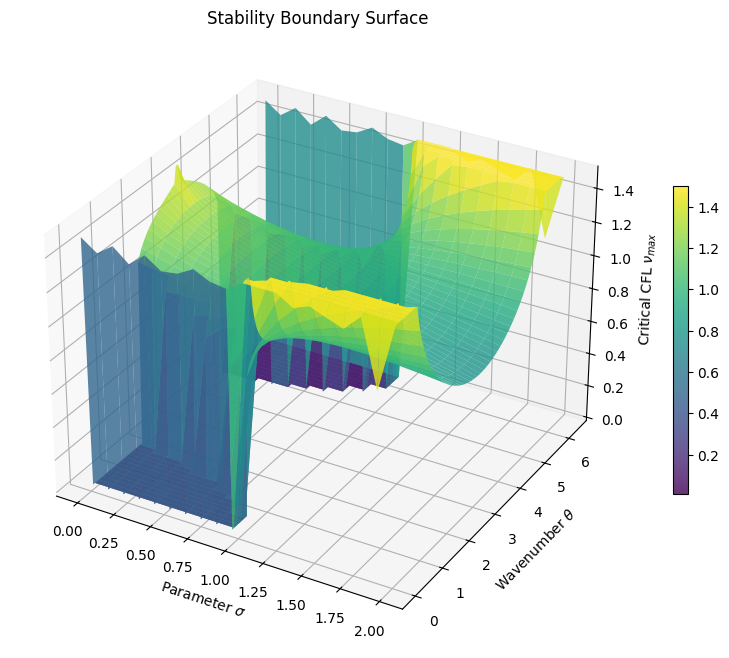

In [481]:
plot_3d_stability_surface()

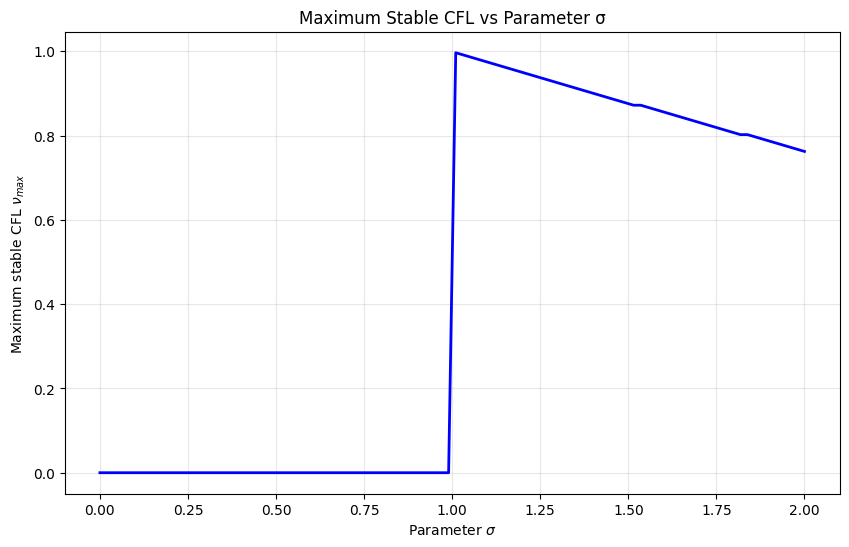

In [482]:
plot_max_cfl_vs_sigma()

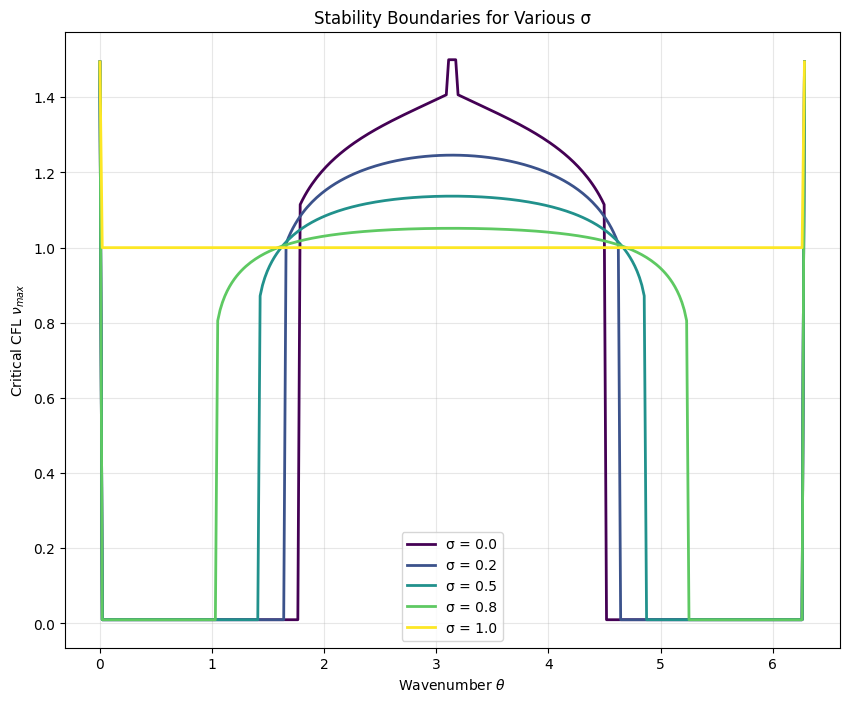

In [483]:
plot_stability_contours_multi_sigma()

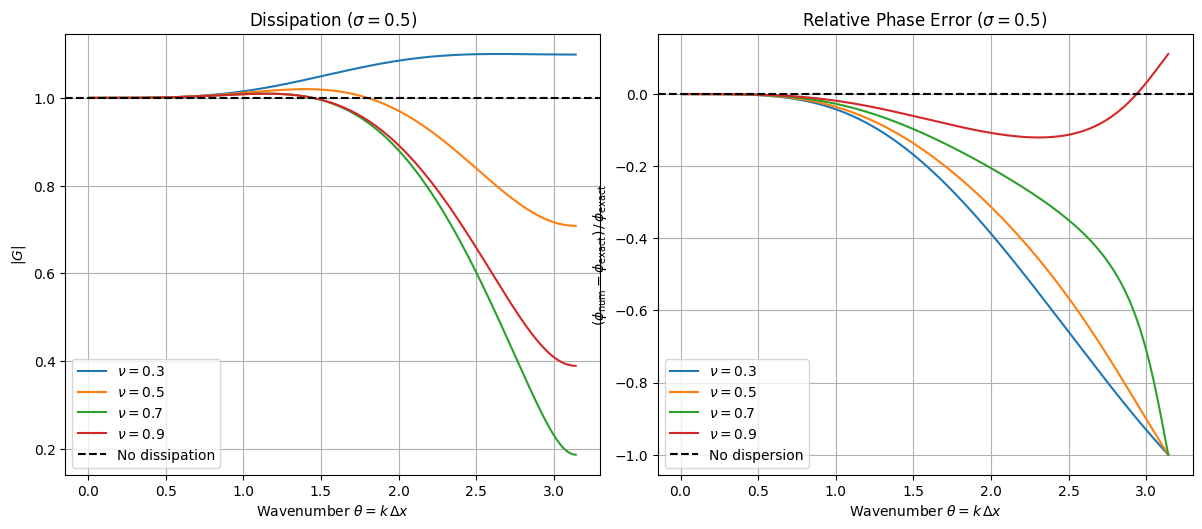

In [ ]:
def dissipation_dispersion(
    sigma_value: np.floating,
    cfl_values: npt.NDArray[np.floating],
    n_theta: int,
):
    theta_values = np.linspace(0.01, np.pi, n_theta)
    # For stacked operation
    cfl_values = np.expand_dims(cfl_values, axis=-1)
    G_values = G_numeric(theta_values, cfl_values, sigma_value)
    phi_numeric = -np.angle(G_values)
    phi_exact = cfl_values * theta_values
    phase_errors = (phi_numeric - phi_exact) / (phi_exact + 1e-12)
    return theta_values, np.abs(G_values), phase_errors


def plot_dissipation(
    theta_values: npt.NDArray[np.floating],
    cfl_values: npt.NDArray[np.floating],
    G_values: npt.NDArray[np.floating],
    sigma_value: np.floating, *,
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, G_values):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(1.0, color='k', linestyle='--', label='No dissipation')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(r'$|G|$')
    ax.set_title(rf'Dissipation ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dispersion(
    theta_values: npt.NDArray[np.floating],
    cfl_values: npt.NDArray[np.floating],
    phase_errors: npt.NDArray[np.floating],
    sigma_value: np.floating, *,
    ax: matplotlib.axes.Axes,
):
    for cfl_value, data in zip(cfl_values, phase_errors):
        ax.plot(theta_values, data, label=fr'$\nu = {cfl_value}$')

    ax.axhline(0.0, color='k', linestyle='--', label='No dispersion')
    ax.set_xlabel(r'Wavenumber $\theta = k\,\Delta x$')
    ax.set_ylabel(
        r'$(\phi_{\mathrm{num}} - \phi_{\mathrm{exact}})\,/\,\phi_{\mathrm{exact}}$'
    )
    ax.set_title(rf'Relative Phase Error ($\sigma = {sigma_value}$)')
    ax.legend()
    ax.grid(True)

    return ax


def plot_dissipation_dispersion(
    sigma_value: np.floating = np.float64(0.5),
    cfl_values: npt.ArrayLike = (0.3, 0.5, 0.7, 0.9),  # pyright: ignore
    n_theta: int = 200,
    axes: tuple[matplotlib.axes.Axes, matplotlib.axes.Axes] | None = None,
):
    cfl_values: npt.NDArray[np.floating] = np.array(cfl_values)
    theta_values, G_values, phase_errors = dissipation_dispersion(
        sigma_value=sigma_value, cfl_values=cfl_values, n_theta=n_theta
    )

    if axes is None:
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.tight_layout()
    axes = typing.cast(tuple[matplotlib.axes.Axes, matplotlib.axes.Axes], axes)

    ax_dissipation, ax_dispersion = axes
    plot_dissipation(
        theta_values=theta_values, cfl_values=cfl_values, G_values=G_values,
        sigma_value=sigma_value, ax=ax_dissipation)
    plot_dispersion(
        theta_values=theta_values, cfl_values=cfl_values,
        phase_errors=phase_errors, sigma_value=sigma_value, ax=ax_dispersion)

    return axes


plot_dissipation_dispersion()
plt.show()

In [485]:
def dissipation_dispersion_analysis():
    """
    Analyze numerical dissipation and dispersion.
    
    For the exact solution: u(x,t) ∝ exp(i(kx - ωt)) with ω = ak (non-dispersive)
    
    Numerical scheme: G = |G| * exp(-i*φ) where
    - |G| < 1 → dissipation (amplitude decay)
    - φ ≠ ν*θ → dispersion (phase error)
    """
    
    print("Dissipation and Dispersion Analysis:")
    print("="*60)
    
    # For exact advection: G_exact = exp(-i*ν*θ)
    G_exact = sp.exp(-sp.I * cfl * theta)
    
    # Numerical phase: φ = -arg(G)
    # Numerical amplitude: |G|
    
    G_trig = G.rewrite(sp.cos, sp.sin)
    G_real_part = sp.trigsimp(sp.re(G_trig))
    G_imag_part = sp.trigsimp(sp.im(G_trig))
    
    print("For phase/dissipation analysis:")
    print("G = |G| * exp(-i*φ_num)")
    print("\nwhere:")
    display(Math(f"|G| = \\sqrt{{(\\Re G)^2 + (\\Im G)^2}}"))
    display(Math(f"\\phi_{{num}} = -\\arctan\\left(\\frac{{\\Im G}}{{\\Re G}}\\right)"))
    
    print("\nExact phase advance per time step:")
    display(Math(f"\\phi_{{exact}} = \\nu \\theta"))
    
    print("\nPhase error (dispersion):")
    display(Math(f"\\epsilon_\\phi = \\phi_{{num}} - \\phi_{{exact}}"))
    
    print("\nDissipation (amplitude ratio per step):")
    display(Math(f"|G| \\text{{ should be }} 1 \\text{{ for no dissipation}}"))
    
    return G_real_part, G_imag_part

G_re, G_im = dissipation_dispersion_analysis()

Dissipation and Dispersion Analysis:
For phase/dissipation analysis:
G = |G| * exp(-i*φ_num)

where:


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Exact phase advance per time step:


<IPython.core.display.Math object>


Phase error (dispersion):


<IPython.core.display.Math object>


Dissipation (amplitude ratio per step):


<IPython.core.display.Math object>

In [486]:
def find_stability_bounds():
    """
    Find constraints on ν (CFL) for stability.
    
    We need |G|² ≤ 1 for all θ. 
    The worst case is typically at θ = π (highest frequency).
    """
    
    print("Stability analysis at θ = π (worst case for many schemes):")
    print("="*60)
    
    G_at_pi = G.subs(theta, sp.pi)
    G_at_pi_simplified = sp.simplify(G_at_pi)
    
    display(Math(f"G(\\pi) = {sp.latex(G_at_pi_simplified)}"))
    
    G_mod_sq_pi = sp.simplify(sp.Abs(G_at_pi_simplified)**2)
    # Stencil is symmetrical => G is real
    G_mod_sq_pi = sp.simplify(G_at_pi_simplified**2)
    
    display(Math(f"|G(\\pi)|^2 = {sp.latex(G_mod_sq_pi)}"))
    
    # Stability: |G(π)|² ≤ 1
    stability_ineq = G_mod_sq_pi - 1
    stability_ineq_simplified = sp.simplify(stability_ineq)
    
    print("\nCondition |G(π)|² - 1 ≤ 0:")
    display(Math(f"{sp.latex(stability_ineq_simplified)} \\leq 0"))
    
    # Solve |G|² = 1 for critical CFL
    try:
        critical_cfl = sp.solve(stability_ineq_simplified, cfl)
        print("\nCritical CFL values (where |G| = 1):")
        for sol in critical_cfl:
            display(Math(f"\\nu = {sp.latex(sp.simplify(sol))}"))
    except Exception as e:
        print(f"Could not solve analytically: {e}")
    
    return G_at_pi_simplified, stability_ineq_simplified

G_pi, stability_pi = find_stability_bounds()

Stability analysis at θ = π (worst case for many schemes):


<IPython.core.display.Math object>

<IPython.core.display.Math object>


Condition |G(π)|² - 1 ≤ 0:


<IPython.core.display.Math object>


Critical CFL values (where |G| = 1):


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>